# **Imports**

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# statistical tools
from scipy.sparse import hstack 
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# set the data for model
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    StandardScaler
)

# models
from sklearn.linear_model import LinearRegression

# evaluations
from sklearn.metrics import(
    mean_absolute_error,
    root_mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

Previouly, we explored the data from **Explanatory Data Analysis idx** files with extracted data **cleaned_data_eda**. We will use that dataset identify the linear models.

# **Data**

Let's call the dataset and identify what variables we have identifying data types.

In [25]:
df = pd.read_csv("cleaned_data_eda.csv")

print("Data Dimension:", df.shape)

df.head()

Data Dimension: (47549, 31)


,ViewYN,PoolPrivateYN,ClosePrice,Latitude,Longitude,LivingArea,CountyOrParish,AttachedGarageYN,ParkingTotal,BathroomsTotalInteger,...,CPI,Age,LotDensity,FlooringType,SchoolDistrict,AgeGroup,CountyOrParish2,FlooringType2,SchoolCount2Miles,SchoolCountGroup
0,1,0,890000.0,34.180411,-118.342020,1434.0,Los Angeles,0,1,1.0,...,315.605,86.0,4.513947,Unknown,Burbank Unified,70+,Los Angeles,Unknown,21.0,20+ Schools
1,0,0,1138000.0,32.574359,-117.023836,2872.0,San Diego,1,6,3.0,...,315.605,25.0,1.817201,Unknown,Unknown,21-40,San Diego,Unknown,12.0,11-20 Schools
2,1,0,681877.0,33.725080,-117.222302,2824.0,Riverside,1,2,3.0,...,315.605,2.0,2.478754,Unknown,Unknown,0-5,Riverside,Unknown,2.0,1-5 Schools
3,1,0,900000.0,34.203479,-118.643567,2500.0,Los Angeles,1,2,3.0,...,315.605,55.0,3.334400,Unknown,Los Angeles Unified,41-70,Los Angeles,Unknown,12.0,11-20 Schools
4,0,0,862000.0,34.460368,-118.490755,2363.0,Los Angeles,1,2,3.0,...,315.605,31.0,4.953449,Unknown,Unknown,21-40,Los Angeles,Unknown,4.0,1-5 Schools


There are 47549 properties of rows and 31 features.

In [26]:
df.dtypes

ViewYN                     int64
PoolPrivateYN              int64
ClosePrice               float64
Latitude                 float64
Longitude                float64
LivingArea               float64
CountyOrParish               str
AttachedGarageYN           int64
ParkingTotal               int64
BathroomsTotalInteger    float64
City                         str
BedroomsTotal            float64
FireplaceYN                int64
Stories                  float64
NewConstructionYN          int64
GarageSpaces             float64
LotSizeSquareFeet        float64
SalesTaxRate             float64
UnemploymentRate         float64
MortgageRate30Fixed      float64
FedInterestRate          float64
CPI                      float64
Age                      float64
LotDensity               float64
FlooringType                 str
SchoolDistrict               str
AgeGroup                     str
CountyOrParish2              str
FlooringType2                str
SchoolCount2Miles        float64
SchoolCoun

Let's divide the features into data types. The ordinal features of **AgegRoup** and **SchoolCountGroup** will not be included due to redundant other features of **Age** and **SchoolCount2Miles**.

In [27]:
# split features by data types

continuous= [
    "Age",
    "CPI",
    "FedInterestRate",
    "Latitude",
    "LivingArea",
    "Longitude",
    "LotDensity",
    "LotSizeSquareFeet",
    "MortgageRate30Fixed",
    "SalesTaxRate",
    "UnemploymentRate"
]

discrete= [
    "BathroomsTotalInteger",
    "BedroomsTotal",
    "Stories",
    "GarageSpaces",
    "ParkingTotal",
    "SchoolCount2Miles"
]

#ordinal = [
#    "AgeGroup",
#    "SchoolCountGroup"
#]

categorical = [
    "CountyOrParish2",
    "FlooringType2",
    "AttachedGarageYN",
    "FireplaceYN",
    "NewConstructionYN",
    "PoolPrivateYN",
    "ViewYN"

]



## 1. Multicollinearity

Checking multicollinearity reduces the stability and interpretability of linear regression coefficients, also it may overfit the model that test data perform worse. The correlation previously detects pairwise multicollinearity.

In [28]:
df_corr = df[["ClosePrice"] + continuous + discrete].corr(
    method="spearman"
)

df_corr

,ClosePrice,Age,CPI,FedInterestRate,Latitude,LivingArea,Longitude,LotDensity,LotSizeSquareFeet,MortgageRate30Fixed,SalesTaxRate,UnemploymentRate,BathroomsTotalInteger,BedroomsTotal,Stories,GarageSpaces,ParkingTotal,SchoolCount2Miles
ClosePrice,1.000000,0.111126,0.036648,-0.021498,-0.228702,0.465690,-0.189887,-0.233608,0.078261,-0.009525,0.049531,0.037578,0.423453,0.325879,0.251953,0.222925,0.221624,0.111576
Age,0.111126,1.000000,-0.001984,0.006189,0.079280,-0.487221,-0.291501,0.320434,-0.045644,0.007160,0.336630,-0.006430,-0.474448,-0.303332,-0.355426,-0.461932,-0.280793,0.554901
CPI,0.036648,-0.001984,1.000000,-0.657001,-0.000209,0.014572,-0.013034,0.003736,0.012454,0.031193,0.005948,0.837492,0.011107,-0.000376,0.001474,0.008248,0.010767,-0.002997
FedInterestRate,-0.021498,0.006189,-0.657001,1.000000,0.014238,-0.007864,-0.005381,-0.003679,-0.009273,-0.378143,0.004068,-0.381795,-0.008674,0.000477,0.006739,-0.010278,-0.010699,0.003458
Latitude,-0.228702,0.079280,-0.000209,0.014238,1.000000,-0.095653,-0.744114,0.127041,0.065576,-0.012589,0.342736,0.005703,-0.112101,-0.048210,-0.061983,-0.111904,-0.266024,-0.009638
LivingArea,0.465690,-0.487221,0.014572,-0.007864,-0.095653,1.000000,0.084310,-0.405490,0.313102,-0.005617,-0.143436,0.016031,0.799488,0.668674,0.525162,0.529751,0.362533,-0.328972
Longitude,-0.189887,-0.291501,-0.013034,-0.005381,-0.744114,0.084310,1.000000,0.029514,0.113384,0.009839,-0.421424,-0.015681,0.087801,0.015010,0.005320,0.132138,0.241952,-0.266234
LotDensity,-0.233608,0.320434,0.003736,-0.003679,0.127041,-0.405490,0.029514,1.000000,0.672572,0.006821,0.010646,-0.001320,-0.418404,-0.294770,-0.501898,-0.125144,-0.047460,-0.018787
LotSizeSquareFeet,0.078261,-0.045644,0.012454,-0.009273,0.065576,0.313102,0.113384,0.672572,1.000000,0.003594,-0.113710,0.008334,0.159525,0.194513,-0.118160,0.271849,0.225515,-0.276955
MortgageRate30Fixed,-0.009525,0.007160,0.031193,-0.378143,-0.012589,-0.005617,0.009839,0.006821,0.003594,1.000000,-0.004921,-0.512921,-0.007205,0.000510,-0.008148,-0.000492,0.002466,0.000873


In [29]:
corr_high = df_corr.where(

    (df_corr.abs() >= 0.7) & (df_corr.abs() < 1)
    
).stack()

corr_high

ClosePrice         ClosePrice          NaN
                   Age                 NaN
                   CPI                 NaN
                   FedInterestRate     NaN
                   Latitude            NaN
                                        ..
SchoolCount2Miles  BedroomsTotal       NaN
                   Stories             NaN
                   GarageSpaces        NaN
                   ParkingTotal        NaN
                   SchoolCount2Miles   NaN
Length: 324, dtype: float64

Those are the variables that has multicollinearity over than  0.7 of absolute coefficients.

- LivingArea vs BathroomsTotalInteger = 0.799 

    - Some redundancy is expected, but both can still contain useful information.

- Latitude vs Longitude = -0.744 

    - Usually keep both. Together they represent geographic position, and removing one can lose important spatial information.

- CPI vs UnemploymentRate = 0.837 

These relationships suggest that some predictors may contain overlapping information. However, correlation alone does not confirm problematic multicollinearity, so additional diagnostics such as Variance Inflation Factor (VIF) can be used before deciding whether a variable should be removed. We will use it later after we provide the linear regression model.


## 2. Split Trainingg and Test Sets

Let's set the dependent and independent variables.

In [30]:
# set the independent and dependent variables.
X = df.drop(columns = ["ClosePrice"])
y = df["ClosePrice"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 48)

Then, we will leverage the standard scaler on continuous numerical variables for similar scale with mean approximately 0 and standard deviation 1. This prevents variables with larger numerical ranges from deproportionate influence on models.

Additionally, we will use get_dummies from pandas to convert the categorical variables into numeric. This would help computational tools to read those variables.

In [31]:
# set the standard scaler 
scaler = StandardScaler()
numeric_features = continuous + discrete

# process the scaler
X_train_num = pd.DataFrame(
    scaler.fit_transform(X_train[numeric_features]),
    columns=numeric_features,
    index=X_train.index
)

X_test_num = pd.DataFrame(
    scaler.transform(X_test[numeric_features]),
    columns=numeric_features,
    index=X_test.index
)


# process the get dummies from categorical varaibles.
X_train_cate = pd.get_dummies(
    X_train[categorical],
    drop_first=True,
    dtype=float
)

X_test_cate = pd.get_dummies(
    X_test[categorical],
    drop_first=True,
    dtype=float
)


X_train_processed =  pd.concat(
    [X_train_num, X_train_cate],
    axis=1
)
X_test_processed = pd.concat(
    [X_test_num, X_test_cate],
    axis=1
)

# **Linear Model**


## 1. Linear Regression

We will try to test the linear models using original and log scaled close price, since we only scaled independent numerical variables. Then, we will explore the lineartiy assumptions better linear models.

In [32]:
# set the formula for stats linear model
linear_train = X_train_processed.copy()

linear_train["ClosePrice"] = y_train

formula = "ClosePrice ~ " + " + ".join(
    [f'Q("{col}")' for col in X_train_processed.columns]
)

# set the linear model using formula
model_linear = smf.ols(formula=formula, data=linear_train).fit()


In [33]:
# test the model
pred_test = model_linear.predict(X_test_processed)
pred_train = model_linear.predict(X_train_processed)

print(f"Test MAPE:, {mean_absolute_percentage_error(y_test, pred_test)*100} %")
print(f"Test RMSE:, ${root_mean_squared_error(y_test, pred_test)}")
print(f"Test MAE:, ${mean_absolute_error(y_test, pred_test)}")
print(f"Test R^2:, {r2_score(y_test, pred_test) * 100} %")
print(f"Test R^2:, {r2_score(y_train, pred_train) * 100} %")


Test MAPE:, 30.12857491190176 %
Test RMSE:, $444297.89068884216
Test MAE:, $286069.47943671123
Test R^2:, 62.70884005442028 %
Test R^2:, 63.23637623046692 %


The linear regression model showed predictive performance in California properties in December 2024 to May 2025:

- **Mean absolute error (MAE), predicted sold price differed from the actual sold prices by about $\$286,000$ on average.**

- **Root mean squared error (RMSE), predicted approximately $\$444,298$ twice as MAE, and it suggests that some properties had especially large prediction errors such as luxury houses.** These larger errors were more penalized by RMSE

- **Mean absolute percentage error (MAPE), predicted approximately $30.1\%$ meaning that predicted sold price was about $30\%$ away from the actual sold price on average.**

- **Test R^2, indicating $62.7\%$ of variation in California property sold prices was explained by fetures included in the linear regression.** The training R^2 is $63.2\%$ **small overfit of 0.5% as acceptable. **

Let's try log scale of close price for normalize the large scale of cost.

In [34]:
# scale close price in log scale
y_train_log = np.log(y_train)
y_test_log = np.log(y_test)


In [35]:
# set the formula for stats linear model with log scaled close price

linear_train = X_train_processed.copy()

linear_train["ClosePriceLog"] = y_train_log

formula = "ClosePriceLog ~ " + " + ".join(
    [f'Q("{col}")' for col in X_train_processed.columns]
)

# set the linear regression 
model_linear_log = smf.ols(formula=formula, data=linear_train).fit()


In [36]:
# test and evaluate the model
pred_test_log = model_linear_log.predict(X_test_processed)
pred_train_log = model_linear_log.predict(X_train_processed)

pred_test_price = np.exp(pred_test_log)
pred_train_price = np.exp(pred_train_log)


print("Log model, original price scale")
print(f"Test MAPE:, {mean_absolute_percentage_error(y_test, pred_test_price)*100} %")
print(f"Test RMSE:, ${root_mean_squared_error(y_test, pred_test_price)}")
print(f"Test MAE:, ${mean_absolute_error(y_test, pred_test_price)}")
print(f"Test R^2:, {r2_score(y_test, pred_test_price) * 100} %")
print(f"Train R^2:, {r2_score(y_train, pred_train_price) * 100} %")


Log model, original price scale
Test MAPE:, 21.10166307225235 %
Test RMSE:, $427280.6592395729
Test MAE:, $240971.50682997066
Test R^2:, 65.51074132803849 %
Train R^2:, 65.87415990597701 %


The log scaled close price in linear regression:

- **The mean absolute error (MAE),  sold price differed from the acutal sold prices by about $\$240,971$ on average. From previous model, it decreased $\$286,069$ to $\$240,972$**.

- **The root mean squared error (RMSE), predicted about $\$427280$ almost twice as MSE, and it shows some properties had large prediction errors. It decreased from $\$444,298$ to $\$427,281$**. 

- **The mean absolute percentage error (MAPE), predicted approximately $21.1\%$ as predicted sold price was about $21\%$ away from actual sold price on average. It decreased from  $30.1\%$ to  $21.1\%$**.

- **The test $R^2$ $65.5\%$ of variation in sold price was explained by features in the model, and the training $R^2$ $\$65.8$ that there is way smaller over fit then previous model**.

In [37]:
model_linear_log.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          ClosePriceLog   R-squared:                       0.758
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     2430.
Date:                Tue, 11 Aug 2026   Prob (F-statistic):               0.00
Time:                        15:12:03   Log-Likelihood:                -4696.7
No. Observations:               38039   AIC:                             9493.
Df Residuals:                   37989   BIC:                             9921.
Df Model:                          49                                         
Covariance Type:            nonrobust                                         
========================================================================================================
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
Intercept                               14.4806      0.022    671.328      0.000      14.438      14.523
Q("Age")                                 0.0616      0.002     26.672      0.000       0.057       0.066
Q("CPI")                                 0.0362      0.037      0.981      0.327      -0.036       0.109
Q("FedInterestRate")                     0.0079      0.016      0.488      0.625      -0.024       0.040
Q("Latitude")                           -0.8744      0.010    -87.334      0.000      -0.894      -0.855
Q("LivingArea")                          0.2351      0.003     78.751      0.000       0.229       0.241
Q("Longitude")                          -0.6523      0.008    -78.208      0.000      -0.669      -0.636
Q("LotDensity")                          0.0111      0.004      2.859      0.004       0.003       0.019
Q("LotSizeSquareFeet")                  -0.0209      0.004     -5.299      0.000      -0.029      -0.013
Q("MortgageRate30Fixed")                -0.0196      0.017     -1.137      0.255      -0.053       0.014
Q("SalesTaxRate")                       -0.0765      0.003    -25.178      0.000      -0.082      -0.071
Q("UnemploymentRate")                   -0.0275      0.034     -0.802      0.423      -0.095       0.040
Q("BathroomsTotalInteger")               0.1030      0.003     39.627      0.000       0.098       0.108
Q("BedroomsTotal")                      -0.0325      0.002    -16.678      0.000      -0.036      -0.029
Q("Stories")                            -0.0460      0.002    -25.825      0.000      -0.049      -0.042
Q("GarageSpaces")                        0.0201      0.002     10.957      0.000       0.017       0.024
Q("ParkingTotal")                        0.0025      0.001      1.730      0.084      -0.000       0.005
Q("SchoolCount2Miles")                  -0.0692      0.002    -35.979      0.000      -0.073      -0.065
Q("AttachedGarageYN")                   -0.0296      0.004     -7.139      0.000      -0.038      -0.021
Q("FireplaceYN")                         0.0454      0.004     12.827      0.000       0.038       0.052
Q("NewConstructionYN")                   0.0964      0.008     11.879      0.000       0.081       0.112
Q("PoolPrivateYN")                       0.0997      0.004     24.079      0.000       0.092       0.108
Q("ViewYN")                              0.0396      0.003     12.509      0.000       0.033       0.046
Q("CountyOrParish2_Butte")               0.1131      0.020      5.594      0.000       0.073       0.153
Q("CountyOrParish2_Contra Costa")       -0.2571      0.010    -25.767      0.000      -0.277      -0.238
Q("CountyOrParish2_Fresno")             -0.7734      0.024    -31.688      0.000      -0.821      -0.726
Q("CountyOrParish2_Kern")             

The log scaled close price of linear regression based on training set shows :

- The $R^2$ of $0.758$, the **features explain approximately $75.8\%$ of the variation in log transformed California properties sold price in training data.**

- The adjusted $R^2$ of $0.758$, indicating the adjusted $R²$ was nearly identical to the $R²$ because the dataset contained a large number of observations relative to the number of predictors. Therefore, the adjustment for model complexity was small.

- The null hypothesis is "None of the features have a linear relationship with log close price", and alternative hypothesis is " **At least one feature explain variation of sold price." In The F statistics is $2430$ and the p-value is $0.00$**, indicating that we reject the null hypothesis and it suggests that a**t least one feature in the model is significantly associated with log transformed sold prices**, and regression model is statistically significant.

    - For individual predictors,
        
        - The features of **CPI** (p = 0.327), **FedInterestRate** (p = 0.625), **MortgageRate30Fixed** (p = 0.255), **UnemploymentRate** (p = 0.423), **ParkingTotal** (p = 0.084), **FlooringType2_Laminate** (p = 0.056), and **FlooringType2_SeeRemarks** (p = 0.466) are not significant at 0.05 level. Also, the confidence interval of 90% of those individual features have 0 included in the interval, indicating that fail to reject null hypothesis and there is not significant evidence that feature has linear relationship with close price.

        - Other features that are p-value less then 0.05 are significant that associated with close price.


- A positive coefficient indicates that higher values of the predictor are associated with higher predicted log sale prices, while a negative coefficient indicates an association with lower predicted log sale prices, holding the other variables constant.

    - **Caution, UnemploymentRate, CPI, LivingArea, BathroomsTotal, Longitude, and Latitude are multicollinear, and coeficient magnitudes and signs should be interpreted cautiously.**


- The Durbin-Watson of 1.995 closer to 2, indicating the errors do not show evidence of serious autocorrelation, and errors assumption appears to be reasonably satisfied.

- The null hypothesis of normality test, null is "Errors are normally distributed", and alternative is "Errors are not normally distributed". Jarque_Bera of 9387.01 with p-value 0.00 less than 0.05 significant level, **we reject the null hypothesis that there is significant evidence to suggest errors are not normally distributed.** 

    - The skewness of 0.432 indicates some right skew, while kuorosis of 5.275 shows heavior tails than normal distribution.

    - **It might suggest that the normality assumption was not fully satisfied.**




## 2. Linear Assumptions

Let's check the linearity assumptions if our data is satisfied using linear model.

### 1) Residuals (Errors) Normal Distribution

We will check whether the errors are approximately normally distributed.

<Figure size 1500x1500 with 0 Axes>

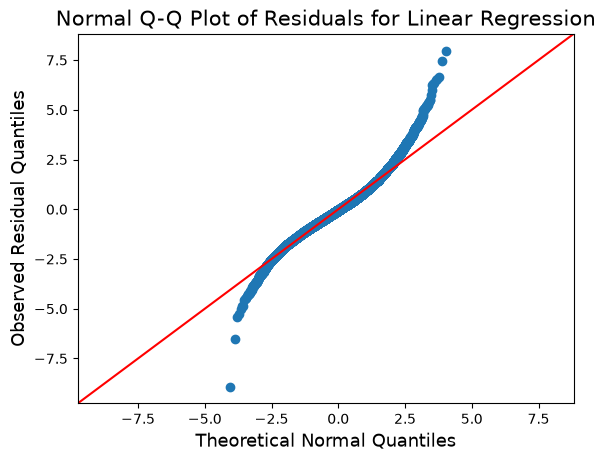

In [38]:
# calculate the model residuals
residuals = model_linear_log.resid

# show the q-q plot for residuals
plt.figure(figsize = (15, 15))
sm.qqplot(residuals, line = "45", fit = True)
plt.title("Normal Q-Q Plot of Residuals for Linear Regression", fontsize= 15)
plt.xlabel("Theoretical Normal Quantiles", fontsize = 13)
plt.ylabel("Observed Residual Quantiles", fontsize = 13)
plt.show()

Based on the plot :

- The x-axis shows the residuals would be expected to fall if it is normal. The y-axis shows what we observed the residuals from our model.

- The middle points follows the red line fairly well, but tails on both sides far off from red line, especially extremes points. 

- This supports previous Jarque-Bera that **residuals are not perfectly normally distributed.**

### 2) Linear Relationship

Let's check of or features can explain our target feature of close price well.

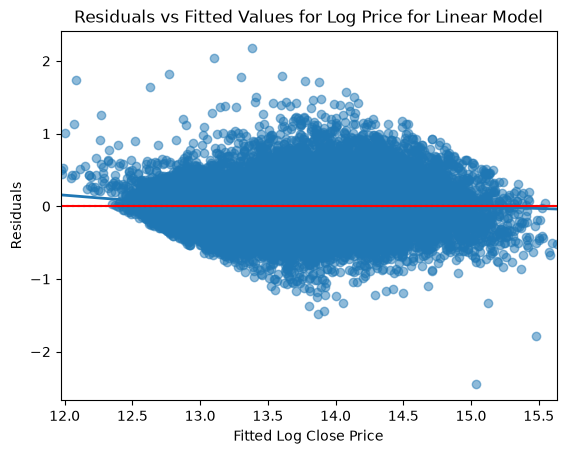

In [39]:
fitted = model_linear_log.fittedvalues

sns.residplot(
    x= fitted,
    y = residuals,
    lowess = True,
    scatter_kws = {"alpha": 0.5},
    line_kws={"linewidth": 2}
)

plt.axhline(0, color='red', linestyle = "-")
plt.title("Residuals vs Fitted Values for Log Price for Linear Model")
plt.xlabel("Fitted Log Close Price")
plt.ylabel("Residuals")
plt.show()

In this residuals plot :

- The middle points spread out evenly from negative to positive based on 0 residual.

- While the lower and higher fitted log close price value becomes narrower with few amount of points that are uneven with positvie negative residuals spread. 

- The variance around 0 residuals are not fully constant on lower and higher points, which it is not constant variance assumption may not fully satisfied.

### 3) Multicollinearity

VIF detects multicollinearity involving combinnations of all features together. Let's check if there is multicollinearity leveraging VIF. Let's check the multicollinearity using VIF if the model has serious mulcollinear for some features.

- VIF less than 5: Prefered

- VIF between 5 to 10: acceptable mild multicollinearity

- VIF greater than 10: Strong and serious multicollinearity

In [40]:
# check the vif chart for multicollinearity
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X_train_processed.values, i) for i in range(X_train_processed.values.shape[1])]
vif["features"] = X_train_processed.columns

vif

,VIF Factor,features
0,2.695275,Age
1,691.526177,CPI
2,132.492158,FedInterestRate
3,37.501672,Latitude
4,4.512028,LivingArea
5,30.081510,Longitude
6,7.674410,LotDensity
7,7.857342,LotSizeSquareFeet
8,150.439237,MortgageRate30Fixed
9,4.552984,SalesTaxRate


The VIF chart shows :

- **CPI** $691.5$, **UnemploymentRate** $596.6$, **MortgageRate30Fixed** $150.4$, **FedInterestRate** $132.5$, **Latitude** $37.5$, **Longitude** $30.1$, these features are serious multicollinearity that can be predicted very strongly from combinations of other predictors. The linear regression has difficulty seperating their individual effects.

- The macroeconomic variables are the clearest example. CPI, unemployment, mortgage rates, and the federal interest rate all move over time, so they likely contain a lot of overlapping information.

- **Our overall prediction can still be useful, but coefficient interpretation becomes less reliable**. a variable may appear insignificant or have an unexpected coefficient sign because its information overlaps heavily with other predictors.

- **Therefore, the assumption of low multicollinearity was not fully satisfied, so p-values, standard errors, coefficients, and confidence intervals should be interpreted cautiously.**

### 4) Homoscedasticity Assumption 

Let's check if the residuals are roughly the same variance or spread acroos the full range of fitted values.

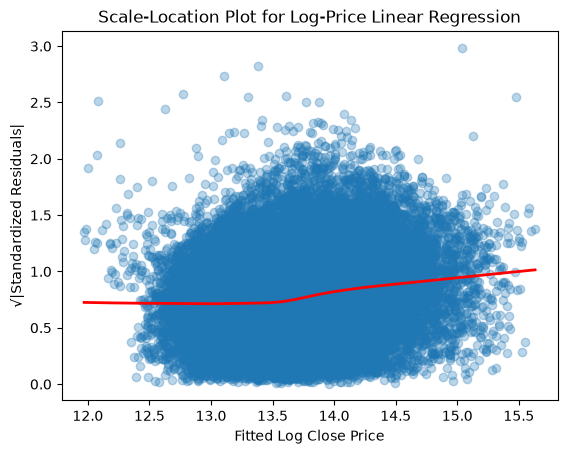

In [41]:
standardized_residuals = residuals / np.std(residuals)

scaled_resid = np.sqrt(np.abs(standardized_residuals))

scale_df = pd.DataFrame({
    "Fitted Log Close Price": fitted,
    "Sqrt Absolute Standardized Residuals": scaled_resid
})

sns.regplot(
    data=scale_df,
    x="Fitted Log Close Price",
    y="Sqrt Absolute Standardized Residuals",
    lowess=True,
    scatter_kws={"alpha": 0.3},
    line_kws={"linewidth": 2, "color": "red"}
)

plt.title("Scale-Location Plot for Log-Price Linear Regression")
plt.xlabel("Fitted Log Close Price")
plt.ylabel("√|Standardized Residuals|")
plt.show()

The scaled location plot shows :

- The red smooth liine is not fully flat that it gradually rises as fited values increase. 

- The typical magnitude of residuals becomes larger at higher prdicted log sold price.

- The homoscedasicity assumption is not perfectly satisfied that it should be flat red line.

## Summary

- The original linear model produced a test MAPE of about $30.1\%$, MAE of about $\$286,069$, RMSE of about $\$444,298$, and test $R^2$ of approximately $62.7\%$. After applying a logarithmic transformation to the sale price, predictive performance improved, with MAPE decreasing to $21.1\%$, MAE to approximately $\$240,972$, RMSE to approximately $\$427,281$, and test $R^2$ increasing to about 65.5% on the original price scale.


## Takeaway

- The main takeaway is that log-transforming housing prices produced a better linear baseline, suggesting that California housing prices are better represented on a logarithmic rather than raw-dollar scale. However, data do not perfectly meet all classical linear regression assumptions.

- The model showed relatively good overall explanatory ability, but individual coefficient interpretation should be treated carefully because several predictors displayed substantial multicollinearity.

- The residual analysis also indicated departures from normality and some non-constant error variance. 

- Therefore, it may be useful for prediction, but it may not fully capture the complexity and nonlinear relationships of the housing market.


## Limitation

- The linear regression model had several limitations. VIF analysis identified substantial multicollinearity, particularly among CPI, Unemployment Rate, Federal Interest Rate, Mortgage Rate, Latitude, and Longitude, making individual coefficient estimates, p-values, and confidence intervals less stable.

- Residual diagnostics also showed that the normality assumption was not fully satisfied, with the Q-Q plot showing deviations in the tails and the Jarque-Bera test rejecting residual normality.

- In addition, the Scale-Location and residual-versus-fitted plots suggested changing residual variance across predicted prices, indicating some heteroscedasticity.

- Therefore, although the model provides a useful baseline, its statistical inference and individual coefficient interpretations should be made cautiously.

## Future Work

- Future work should evaluate more flexible predictive approaches that can better capture nonlinear relationships and interactions among housing characteristics. Tree-based models such as Random Forest and XGBoost can model complex relationships without requiring the strict linearity assumptions.
